In [1]:
from pystac_client import Client
import joblib
from typing import Any
import os
import requests
from datetime import date
from loguru import logger

In [2]:
from utils.constants import GHANA_GDF, GH_ASHANTI_GDF, SENTINEL_SCENES_FOLDERPATH, SILVER_FOLDERPATH, EARCH_SEARCH_API_URL, SENTINEL_BANDS, SENTINEL_ASHANTI_SCENE_IDS_FILEPATH
from utils.site import Site
from utils.search_result import SearchResult

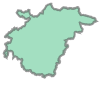

In [3]:
GH_ASHANTI_GDF.geometry.iloc[0]

In [4]:
# Search all Sentinel scenes of Ashanti
client = Client.open(EARCH_SEARCH_API_URL)

search = client.search(
    collections=["sentinel-2-l2a"],
    intersects=GH_ASHANTI_GDF.geometry.iloc[0],
    datetime="2020-01-01/2020-01-30",  # e.g. "2020-01-01/2021-01-30"
    query={"eo:cloud_cover": {"lt": 20}},
)
all_scenes = list(search.items())
print(f"Found {len(all_scenes)} total scenes.")

Found 129 total scenes.


In [5]:
# Dictionary to hold the best scene for each specific tile
tile_id_to_best_scene = {}

for scene in all_scenes:
    tile_id = scene.id.split("_")[1]
    cloud_cover = scene.properties.get("eo:cloud_cover", 100)
    
    # If we haven't seen this tile yet, OR if the current scene is less cloudy than the saved one
    if tile_id not in tile_id_to_best_scene:
        tile_id_to_best_scene[tile_id] = scene
    elif cloud_cover < tile_id_to_best_scene[tile_id].properties.get("eo:cloud_cover", 100):
        tile_id_to_best_scene[tile_id] = scene

print(f"Filtered down to {len(tile_id_to_best_scene)} unique tiles to cover the region.")
for tile_id, best_scene in tile_id_to_best_scene.items():
    print(f"- Tile {tile_id} | Cloud cover {best_scene.properties.get("eo:cloud_cover"):.2f}")

Filtered down to 11 unique tiles to cover the region.
- Tile 30NWN | Cloud cover 0.00
- Tile 30NWM | Cloud cover 0.01
- Tile 30NXM | Cloud cover 0.02
- Tile 30NYM | Cloud cover 0.04
- Tile 30NXN | Cloud cover 0.00
- Tile 30NYN | Cloud cover 0.00
- Tile 30NZN | Cloud cover 0.02
- Tile 30NWP | Cloud cover 0.00
- Tile 30NXP | Cloud cover 0.00
- Tile 30NYP | Cloud cover 0.00
- Tile 30NZP | Cloud cover 0.00


In [6]:
# Dump
joblib.dump(list(tile_id_to_best_scene.values()), SENTINEL_ASHANTI_SCENE_IDS_FILEPATH)

['/home/aga/Documents/clients/forestero/skymap/skymap/data/silver/ashanti_2020_scene_ids.joblib']

In [7]:
# Download them all
def download_file(url: str, filepath: Path) -> None:
    """Downloads a file using a .part extension to prevent corruption if interrupted."""
    if filepath.exists():
        logger.warning(f"File {filepath.name} already exists. Skipping...")
        return

    part_filepath = filepath.with_suffix(filepath.suffix + ".part")

    response = requests.get(url, stream=True)
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))

    with (
        part_filepath.open("wb") as f,
        tqdm(desc=filepath.name, total=total_size, unit="iB", unit_scale=True, unit_divisor=1024, leave=False) as bar,
    ):
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                size = f.write(chunk)
                bar.update(size)

    part_filepath.rename(filepath)

In [8]:
for tile_id, scene in tile_id_to_best_scene.items():
    logger.info(f"Downloading {tile_id}...")
    scene_folder = SENTINEL_SCENES_FOLDERPATH / scene.id
    scene_folder.mkdir(parents=True, exist_ok=True)

    for band in SENTINEL_BANDS:
        if band in scene.assets:
            download_url = scene.assets[band].href
            filename = f"{scene.id}_{band}.tif"
            filepath = scene_folder / filename

            try:
                SearchResult.download_file(download_url, filepath)
            except Exception as e:
                logger.exception(f"Error downloading {band}: {e}")

2026-04-13 13:28:37.635 | INFO     | __main__:<module>:2 - Downloading 30NWN...
2026-04-13 13:28:37.638 | WARNING  | utils.search_result:download_file:99 - File /home/aga/Documents/clients/forestero/skymap/skymap/data/bronze/sentinel-scenes/S2B_30NWN_20200107_1_L2A/S2B_30NWN_20200107_1_L2A_blue.tif already exists. Skipping...
2026-04-13 13:28:37.640 | WARNING  | utils.search_result:download_file:99 - File /home/aga/Documents/clients/forestero/skymap/skymap/data/bronze/sentinel-scenes/S2B_30NWN_20200107_1_L2A/S2B_30NWN_20200107_1_L2A_green.tif already exists. Skipping...
2026-04-13 13:28:37.642 | WARNING  | utils.search_result:download_file:99 - File /home/aga/Documents/clients/forestero/skymap/skymap/data/bronze/sentinel-scenes/S2B_30NWN_20200107_1_L2A/S2B_30NWN_20200107_1_L2A_red.tif already exists. Skipping...
2026-04-13 13:28:37.644 | WARNING  | utils.search_result:download_file:99 - File /home/aga/Documents/clients/forestero/skymap/skymap/data/bronze/sentinel-scenes/S2B_30NWN_20200